In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from _fractures import *

In [21]:
xmin,ymin,zmin,xmax,ymax,zmax,Nx,Ny,Nz,dx,dy,dz = get_grid_parameters()

In [36]:
##IMPORT DATA AS A CSV FILE

data = pd.read_csv("energies_classical_ricker_IC_1_5x5x5_-1to1_2e-05_0.0001")
#Define whether just classical values will be plotted
quantum = False

In [38]:
#View data
data

,total_quantum,total_classical,kinetic_quantum,kinetic_classical,potential_quantum,potential_classical,time,Layer #
0,0,0.347926,0,0.005042,0,0.342884,0.00002,1
1,0,18.440465,0,16.047403,0,2.393062,0.00002,2
2,0,0.351945,0,0.006986,0,0.344960,0.00002,3
3,0,18.438393,0,16.374408,0,2.063985,0.00002,4
4,0,1.174495,0,0.065068,0,1.109427,0.00004,1
5,0,17.590280,0,9.830391,0,7.759889,0.00004,2
6,0,1.230307,0,0.090311,0,1.139996,0.00004,3
7,0,17.559495,0,10.724132,0,6.835363,0.00004,4
8,0,2.001689,0,0.228200,0,1.773489,0.00006,1
9,0,16.681233,0,4.436346,0,12.244886,0.00006,2


In [39]:
def get_layer_dataframes(data):
    if (Nx<=5):
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4]
    elif (Nx>5 and Nx<=9):
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        data_layer_5 = data[data['Layer #']==5]
        data_layer_6 = data[data['Layer #']==6]
        data_layer_7 = data[data['Layer #']==7]
        data_layer_8 = data[data['Layer #']==8]
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5,data_layer_6,data_layer_7,data_layer_8]
    elif (Nx>9 and Nx<=17):
        data_layer_1 = data[(data['Layer #']==1) | (data['Layer #']==2)]
        data_layer_1 = data_layer_1.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_1['Layer #'] = data_layer_1['Layer #'] - 2
        data_layer_2 = data[(data['Layer #']==3) | (data['Layer #']==4)]
        data_layer_2 = data_layer_2.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_2['Layer #'] = data_layer_2['Layer #'] - 5
        data_layer_3 = data[(data['Layer #']==5) | (data['Layer #']==6)]
        data_layer_3 = data_layer_3.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_3['Layer #'] = data_layer_3['Layer #'] - 8
        data_layer_4 = data[(data['Layer #']==7) | (data['Layer #']==8)]
        data_layer_4 = data_layer_4.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_4['Layer #'] = data_layer_4['Layer #'] - 11
        data_layer_5 = data[(data['Layer #']==9) | (data['Layer #']==10)]
        data_layer_5 = data_layer_5.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_5['Layer #'] = data_layer_5['Layer #'] - 14
        data_layer_6 = data[(data['Layer #']==11) | (data['Layer #']==12)]
        data_layer_6 = data_layer_6.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_6['Layer #'] = data_layer_6['Layer #'] - 17
        data_layer_7 = data[(data['Layer #']==13) | (data['Layer #']==14)]
        data_layer_7 = data_layer_7.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_7['Layer #'] = data_layer_7['Layer #'] - 20
        data_layer_8 = data[(data['Layer #']==15) | (data['Layer #']==16)]
        data_layer_8 = data_layer_8.groupby(["time"]).sum(numeric_only=True).reset_index()
        data_layer_8['Layer #'] = data_layer_8['Layer #'] - 23
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5,data_layer_6,data_layer_7,data_layer_8]

    return data.columns.tolist(),data_layer_1['time'],layer_names

In [42]:
def plot_layer_energy_time(energy_type,times,layer_names):
    for layer in layer_names:
        plt.figure(figsize=(8, 5))
        plt.plot(times,layer['total_classical'] , label='total_classical')
        plt.plot(times, layer['kinetic_classical'], label='kinetic_classical')
        plt.plot(times, layer['potential_classical'], label='potential_classical')
        if quantum:
            plt.plot(times,layer['total_quantum'] , label='total_quantum')
            plt.plot(times, layer['kinetic_quantum'], label='kinetic_quantum')
            plt.plot(times, layer['potential_quantum'], label='potential_quantum')
            

        plt.xlabel('Time')
        plt.ylabel('Energy')
        if quantum:
            plt.title(f'Layer {layer["Layer #"].iloc[0]} Energy vs Time (Quantum and Classical)')
        else:
            plt.title(f'Layer {layer["Layer #"].iloc[0]} Energy vs Time (Classical)')
        plt.legend()
        plt.grid(True)
        plt.show()

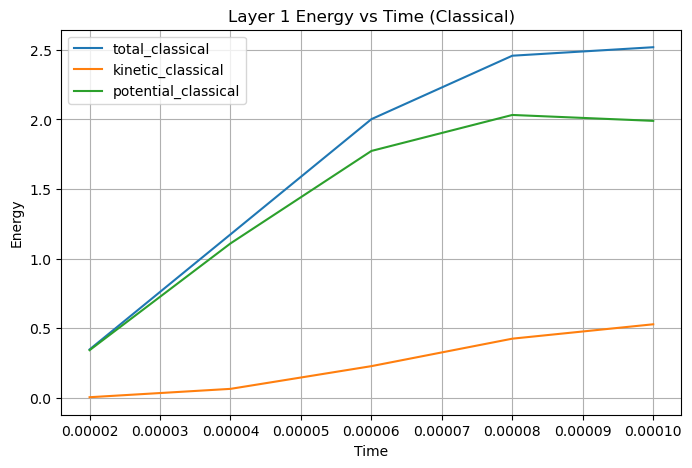

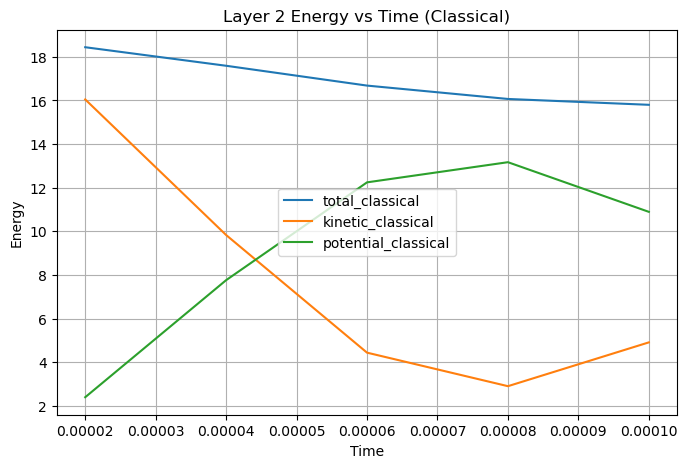

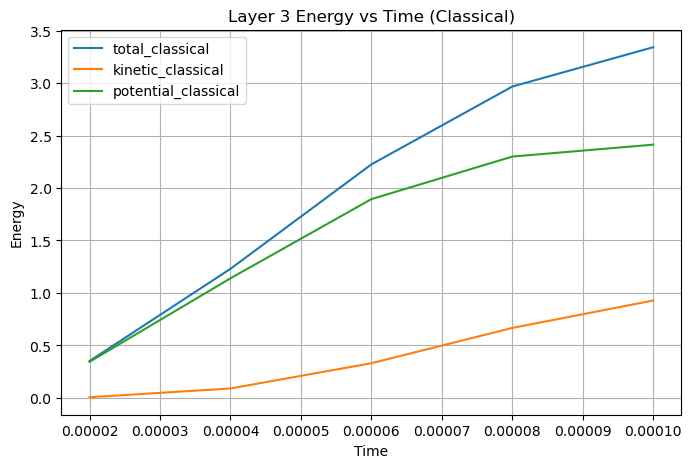

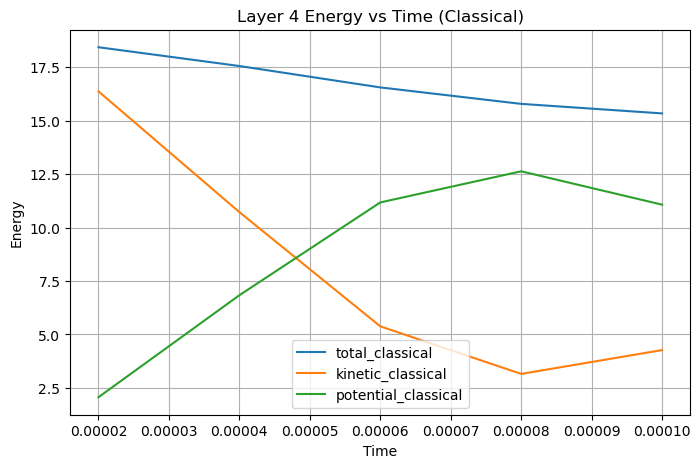

In [44]:
energy_types, times,layer_names = get_layer_dataframes(data)
plot_layer_energy_time(energy_types,times,layer_names)
            